# Pràctica Bloc III

In [256]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import zip_longest

train_raw, test_raw = pd.read_csv("data/train.csv"), pd.read_csv("data/test.csv")
print(f"Dimensions del dataset (train): {train_raw.shape}")
print(f"Dimensions del dataset (test): {test_raw.shape}")
train_raw.head()

Dimensions del dataset (train): (103904, 25)
Dimensions del dataset (test): (25976, 25)


,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


# Preprocessing

In [257]:
# eliminam columnes que no aporten informació
ignore = { "Unnamed: 0", "id" }
train_raw.drop(columns=ignore, inplace=True, errors="ignore")
test_raw.drop(columns=ignore, inplace=True, errors="ignore")
print(train_raw.columns.tolist())

['Gender', 'Customer Type', 'Age', 'Type of Travel', 'Class', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes', 'satisfaction']


In [258]:
# comprovam quines columnes tenen valors invalids (NaNs)
train_raw.isna().sum() + test_raw.isna().sum()

Gender                                 0
Customer Type                          0
Age                                    0
Type of Travel                         0
Class                                  0
Flight Distance                        0
Inflight wifi service                  0
Departure/Arrival time convenient      0
Ease of Online booking                 0
Gate location                          0
Food and drink                         0
Online boarding                        0
Seat comfort                           0
Inflight entertainment                 0
On-board service                       0
Leg room service                       0
Baggage handling                       0
Checkin service                        0
Inflight service                       0
Cleanliness                            0
Departure Delay in Minutes             0
Arrival Delay in Minutes             393
satisfaction                           0
dtype: int64

In [259]:
# reempleçam els NaNs per a la mitjana de la seva columna
nancol = "Arrival Delay in Minutes"
train_raw[nancol] = train_raw[nancol].fillna(train_raw[nancol].mean())
test_raw[nancol] = test_raw[nancol].fillna(test_raw[nancol].mean())
train_raw.isna().sum() + test_raw.isna().sum()

Gender                               0
Customer Type                        0
Age                                  0
Type of Travel                       0
Class                                0
Flight Distance                      0
Inflight wifi service                0
Departure/Arrival time convenient    0
Ease of Online booking               0
Gate location                        0
Food and drink                       0
Online boarding                      0
Seat comfort                         0
Inflight entertainment               0
On-board service                     0
Leg room service                     0
Baggage handling                     0
Checkin service                      0
Inflight service                     0
Cleanliness                          0
Departure Delay in Minutes           0
Arrival Delay in Minutes             0
satisfaction                         0
dtype: int64

In [260]:
# these are the columns with a level of satisfaction values in [0-5]
lvlcols = { "Inflight wifi service", "Departure/Arrival time convenient", "Ease of Online booking", "Gate location",
           "Food and drink", "Online boarding", "Seat comfort", "Inflight entertainment", "On-board service",
           "Leg room service", "Baggage handling", "Checkin service", "Inflight service", "Cleanliness" }
# get columns without numeric values
catcols = set(train_raw.select_dtypes(exclude=[np.number]).columns)
# get columns with numeric values 
numcols = set(train_raw.select_dtypes(include=[np.number]).columns)
numcols ^= lvlcols # remaining columns that are numeric but do not represent a satisfacion level

numcols, lvlcols, catcols = map(list, (numcols, lvlcols, catcols))

# convert columns with categoric values to numeric values
catvals = { col: list(train_raw[col].unique()) for col in catcols }

lalign = 4
sep = "-" * 80

print("Columns with categoric values")
lmax = max(len(s) for s in catcols)
print("\n".join(" " * lalign + f"{col:{lmax}s} : {catvals[col]}" for col in catcols))
print(sep)

print("Columns with satisfaction level values [0-5]")
print("\n".join(" " * lalign + col for col in lvlcols))
print(sep)

print("Columns with numeric values")
print("\n".join(" " * lalign + col for col in numcols))

Columns with categoric values
    Gender         : ['Male', 'Female']
    satisfaction   : ['neutral or dissatisfied', 'satisfied']
    Type of Travel : ['Personal Travel', 'Business travel']
    Customer Type  : ['Loyal Customer', 'disloyal Customer']
    Class          : ['Eco Plus', 'Business', 'Eco']
--------------------------------------------------------------------------------
Columns with satisfaction level values [0-5]
    Cleanliness
    Departure/Arrival time convenient
    Leg room service
    Inflight entertainment
    Seat comfort
    Checkin service
    Inflight service
    Food and drink
    Ease of Online booking
    Inflight wifi service
    Baggage handling
    Gate location
    Online boarding
    On-board service
--------------------------------------------------------------------------------
Columns with numeric values
    Flight Distance
    Departure Delay in Minutes
    Arrival Delay in Minutes
    Age


# Preview

In [261]:
# n = len(catcols)
# ncols = 3
# nrows = int(np.ceil(n / ncols))
# fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
# axes = axes.ravel()

# for ax, col in zip_longest(axes, catcols):
#   if col:
#     sns.countplot(data=train_raw, x=col, ax=ax)
#     ax.set_title(col)
#     labels = list(catvals[col])
#     ax.set_xticks(np.arange(0, len(labels)), labels)
#     ax.set_xlabel("")
#   else:
#     ax.axis("off")

# plt.tight_layout()
# plt.show()

In [262]:
# n = len(lvlcols)
# ncols = 3
# nrows = int(np.ceil(n / ncols))
# fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
# axes = axes.ravel()

# for ax, col in zip_longest(axes, lvlcols):
#   if col:
#     sns.countplot(data=train_raw, x=col, ax=ax)
#     ax.set_title(col)
#     ax.set_xlabel("")
#   else:
#     ax.axis("off")

# plt.tight_layout()
# plt.show()

In [263]:
# cols = ["Departure Delay in Minutes", "Arrival Delay in Minutes"]
# n = len(cols)
# ncols = 2
# nrows = int(np.ceil(n / ncols))
# fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
# axes = axes.ravel()

# from matplotlib.ticker import LinearLocator

# for ax, col in zip_longest(axes, cols):
#   if col:
#     sns.countplot(data=train_raw, x=col, ax=ax)
#     ax.set_title(col)
#     m = train_raw[col].max()
#     ax.set_ylim(0, m * 1.5)
#     ax.xaxis.set_major_locator(LinearLocator(numticks=10))
#     ax.set_xlabel("")
#   else:
#     ax.axis("off")

# plt.tight_layout()
# plt.show()

In [264]:
# cols = ["Flight Distance", "Age"]
# n = len(cols)
# ncols = 2
# nrows = int(np.ceil(n / ncols))
# fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
# axes = axes.ravel()

# for ax, col in zip_longest(axes, cols):
#   if col:
#     sns.countplot(data=train_raw, x=col, ax=ax)
#     ax.set_title(col)
#     ax.xaxis.set_major_locator(LinearLocator(numticks=10))
#     ax.set_xlabel("")
#   else:
#     ax.axis("off")

# plt.tight_layout()
# plt.show()

# Clustering

In [265]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, OneHotEncoder

trgcol = "satisfaction"
trgmap = {"neutral or dissatisfied": 0, "satisfied": 1}
enc = OneHotEncoder(drop="if_binary", sparse_output=False)
cat = pd.DataFrame(enc.fit_transform(train_raw[catcols].drop(columns=[trgcol])), columns=enc.get_feature_names_out())
train = pd.concat([train_raw.drop(columns=catcols), cat, train_raw[trgcol].map(trgmap)], axis=1)
train

,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,...,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,Gender_Male,Type of Travel_Personal Travel,Customer Type_disloyal Customer,Class_Business,Class_Eco,Class_Eco Plus,satisfaction
0,13,460,3,4,3,1,5,3,5,5,...,5,25,18.0,1.0,1.0,0.0,0.0,0.0,1.0,0
1,25,235,3,2,3,3,1,3,1,1,...,1,1,6.0,1.0,0.0,1.0,1.0,0.0,0.0,0
2,26,1142,2,2,2,2,5,5,5,5,...,5,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1
3,25,562,2,5,5,5,2,2,2,2,...,2,11,9.0,0.0,0.0,0.0,1.0,0.0,0.0,0
4,61,214,3,3,3,3,4,5,5,3,...,3,0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103899,23,192,2,1,2,3,2,2,2,2,...,2,3,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0
103900,49,2347,4,4,4,4,2,4,5,5,...,4,0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1
103901,30,1995,1,1,1,3,4,1,5,4,...,4,7,14.0,1.0,0.0,1.0,1.0,0.0,0.0,0
103902,22,1000,1,1,1,5,1,1,1,1,...,1,0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0


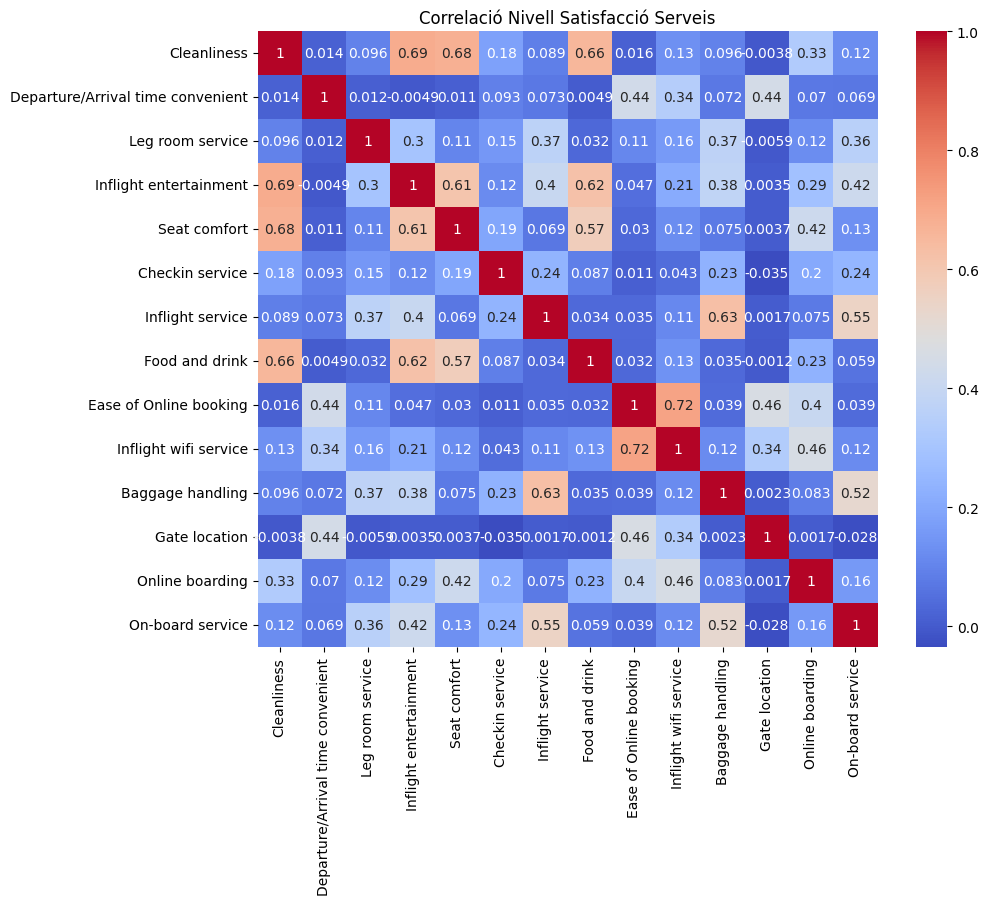

In [266]:
plt.figure(figsize=(10, 8))
sns.heatmap(train[lvlcols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlació Nivell Satisfacció Serveis")
plt.show()

In [267]:
groups = [
  ("Flight comfort (mean)", ["Food and drink", "Seat comfort", "Inflight entertainment", "Cleanliness"]),
  ("Flight service (mean)", ["Baggage handling", "On-board service", "Inflight service"]),
  ("Online service (mean)", ["Ease of Online booking", "Inflight wifi service", "Online boarding"])
]
for name, group in groups:
  train[name] = train[group].mean(axis=1)
  train = train.drop(columns=group)
  lvlcols = list(set(lvlcols) - set(group)) + [name]
lvlcols

['Departure/Arrival time convenient',
 'Leg room service',
 'Checkin service',
 'Flight comfort (mean)',
 'Gate location',
 'Flight service (mean)',
 'Online service (mean)']

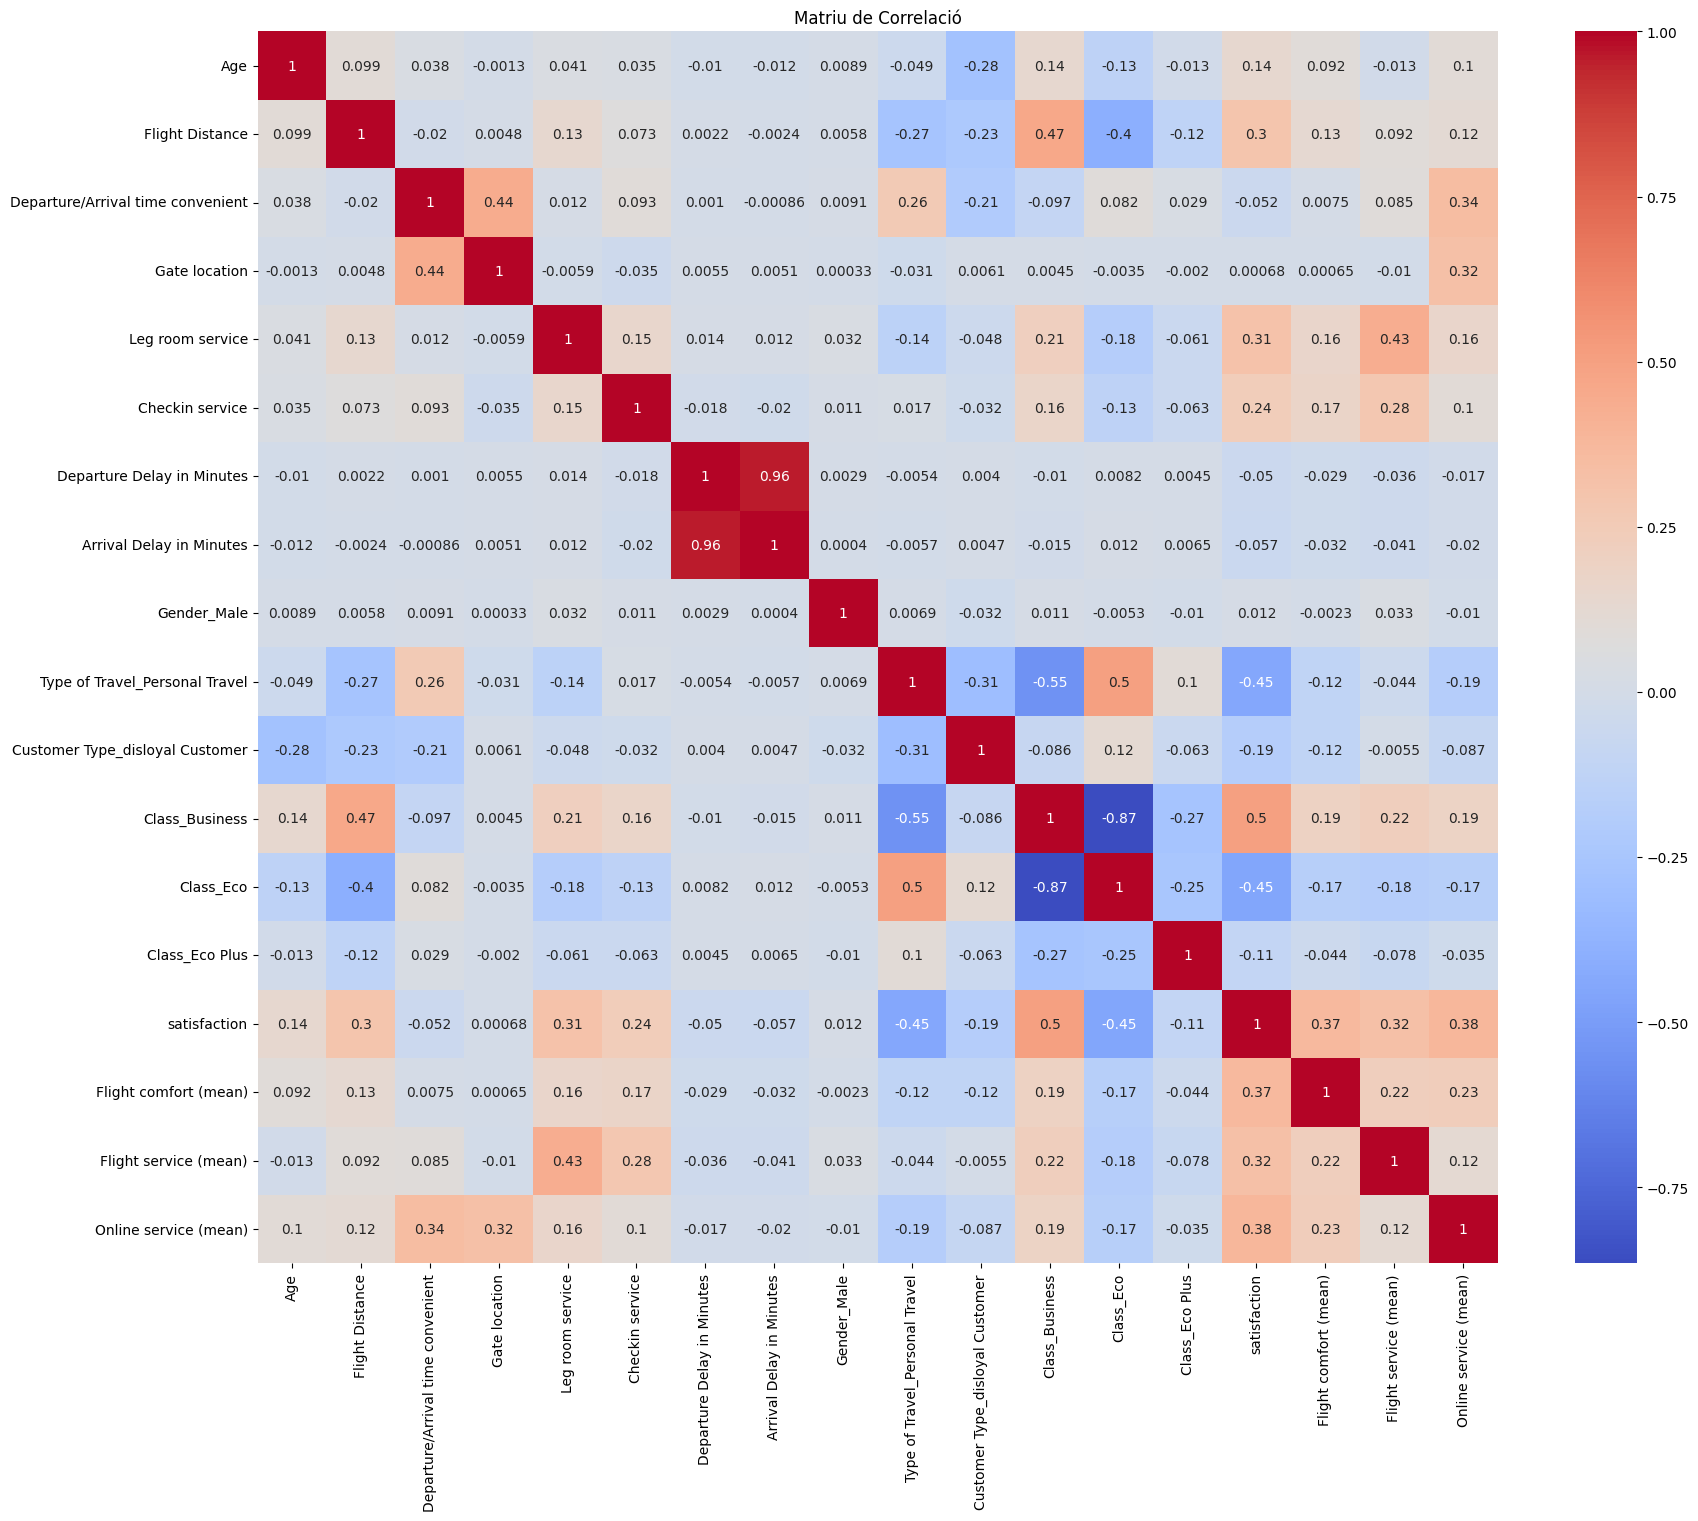

In [268]:
plt.figure(figsize=(20, 16))
sns.heatmap(train.corr(), annot=True, cmap='coolwarm')
plt.title("Matriu de Correlació")
plt.show()

In [269]:
ignore = ["Departure/Arrival time convenient", "Gate location","Gender_Male", "Departure Delay in Minutes", "Arrival Delay in Minutes"]
train = train.drop(columns=ignore)

Y_train = train[trgcol]
X_train = train.drop(columns=[trgcol])

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
print(f"shape: {X_train_scaled.shape}")

shape: (103904, 12)


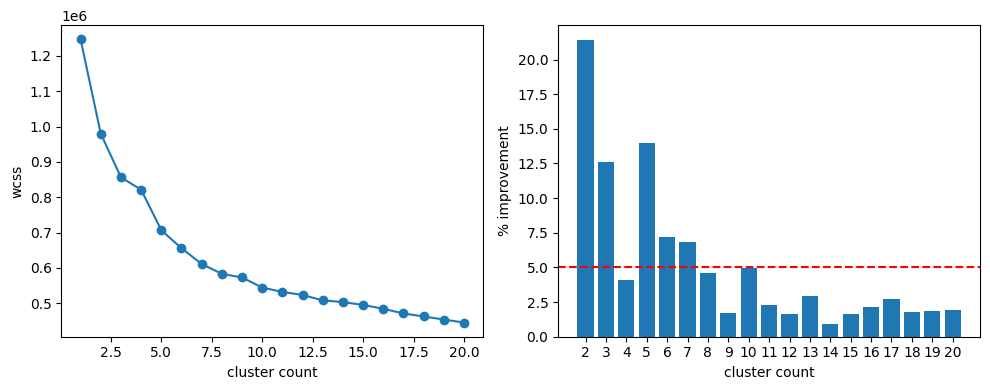

 1 ->  2 :  21.41%
 2 ->  3 :  12.61%
 3 ->  4 :   4.09%
 4 ->  5 :  13.97%
 5 ->  6 :   7.21%
 6 ->  7 :   6.80%
 7 ->  8 :   4.58%
 8 ->  9 :   1.74%
 9 -> 10 :   4.99%
10 -> 11 :   2.28%
11 -> 12 :   1.60%
12 -> 13 :   2.94%
13 -> 14 :   0.94%
14 -> 15 :   1.63%
15 -> 16 :   2.17%
16 -> 17 :   2.75%
17 -> 18 :   1.80%
18 -> 19 :   1.86%
19 -> 20 :   1.89%


In [270]:
cnt = np.arange(1, 20 + 1)
wcss = np.zeros(len(cnt))
for i in cnt:
  kmeans = KMeans(n_clusters=i, init="k-means++", random_state=420)
  kmeans.fit(X_train_scaled)
  wcss[i-1] = kmeans.inertia_

change_cnt = np.concat([cnt[:-1].reshape(-1, 1), cnt[1:].reshape(-1, 1)], axis=1)
change_pct = (wcss[:-1] - wcss[1:]) / wcss[:-1] * 100

fig, (ax_wcss, ax_change) = plt.subplots(1, 2, figsize=(5 * 2, 4))

ax_wcss.plot(cnt, wcss, marker="o")
ax_wcss.set_xlabel("cluster count")
ax_wcss.set_ylabel("wcss")

ax_change.bar(cnt[1:], change_pct)
ax_change.set_xticks(cnt[1:])
ax_change.set_xlabel("cluster count")
ax_change.set_ylabel("% improvement")
ax_change.axhline(y=5, color='red', linestyle='--')

plt.tight_layout()
plt.show()

for (c1, c2), p in zip(change_cnt, change_pct): print(f"{c1:2d} -> {c2:2d} : {p:6.2f}%")

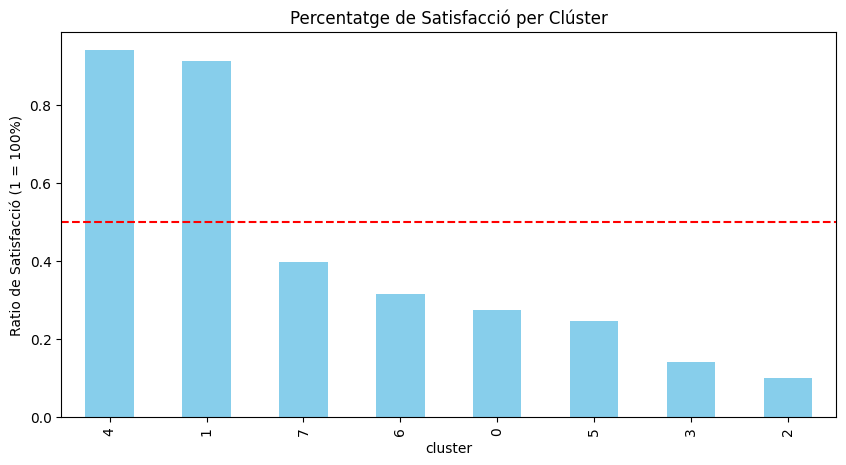

In [272]:
kmeans = KMeans(n_clusters=8, random_state=420)
cluster = train.copy()
cluster["cluster"] = kmeans.fit_predict(X_train_scaled)

satisfaction_per_cluster = cluster.groupby("cluster")["satisfaction"].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
satisfaction_per_cluster.plot(kind='bar', color='skyblue')
plt.axhline(y=0.5, color='red', linestyle='--') # Línia del 50%
plt.title("Percentatge de Satisfacció per Clúster")
plt.ylabel("Ratio de Satisfacció (1 = 100%)")
plt.show()

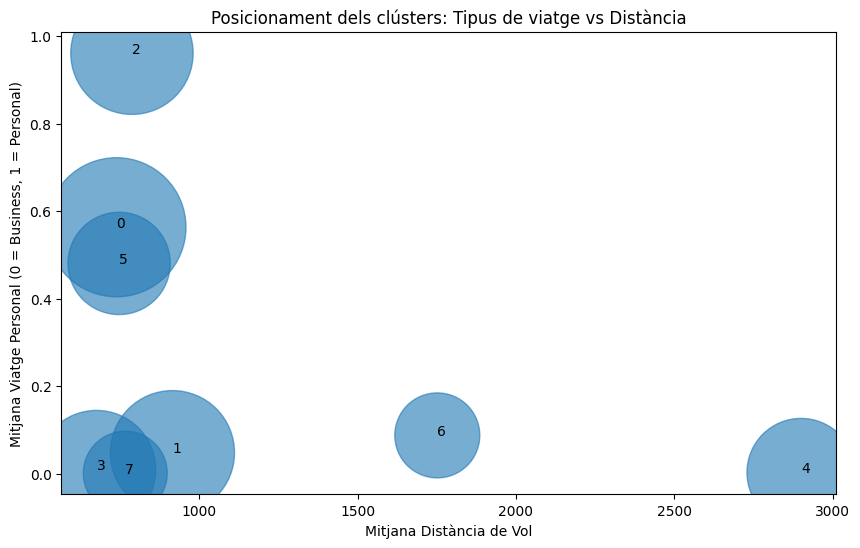

In [273]:
# Necessitem identificar quina columna és 'Type of Travel' (Business) i 'Flight Distance'
# Suposem que 'Type of Travel_Personal Travel' és la columna binària (on 0 és Business)
cluster_summary = cluster.groupby("cluster").mean()

plt.figure(figsize=(10, 6))
plt.scatter(cluster_summary['Flight Distance'], 
            cluster_summary['Type of Travel_Personal Travel'], 
            s=cluster['cluster'].value_counts()*0.5, # Mida segons el nombre de passatgers
            alpha=0.6)

for i, txt in enumerate(cluster_summary.index):
  plt.annotate(txt, (cluster_summary['Flight Distance'][i], cluster_summary['Type of Travel_Personal Travel'][i]))

plt.title("Posicionament dels clústers: Tipus de viatge vs Distància")
plt.xlabel("Mitjana Distància de Vol")
plt.ylabel("Mitjana Viatge Personal (0 = Business, 1 = Personal)")
plt.show()

TODO:

- Try to add "Arrival Delay" to see if it affects the clustering
- Try to merge some satisfacion level features to decrease dimensionality

# Training

In [107]:
# from sklearn.svm import SVC
# from sklearn.tree import DecisionTreeClassifier
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.linear_model import Perceptron, LogisticRegression
# from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# models = {
#   "Perceptron": Perceptron(max_iter=1000),
#   "Logistic Regression": LogisticRegression(max_iter=1000),
#   "SVM": SVC(max_iter=1000),
#   "Tree": DecisionTreeClassifier(),
#   "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
# }

# for name, model in models.items():
#   print(f"******** {name} ********")

#   model.fit(X_train_scaled, y_train)

#   y_train_pred = model.predict(X_train_scaled)
#   y_test_pred = model.predict(X_test_scaled)

#   acc_train = accuracy_score(y_train, y_train_pred)
#   acc_test = accuracy_score(y_test, y_test_pred)

#   print(f"train acc: {acc_train:6.4f}")
#   print(f" test acc: {acc_test:6.4f}")

#   if acc_train - acc_test > 0.1: print("WARNING: possible overfitting")

#   print()